# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 15.7 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
dataframes = {
    'df_hh_income': df_hh_income,
    'df_pct_poverty': df_pct_poverty,
    'df_pct_completed_hs': df_pct_completed_hs,
    'df_share_race_city': df_share_race_city,
    'df_fatalities': df_fatalities
}

for name, df in dataframes.items():
  print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

df_hh_income: 29322 rows, 3 columns
df_pct_poverty: 29329 rows, 3 columns
df_pct_completed_hs: 29329 rows, 3 columns
df_share_race_city: 29268 rows, 7 columns
df_fatalities: 2535 rows, 14 columns


In [6]:
for name, df in dataframes.items():
  print(f"\n{name} columns:")
  print(list(df.columns))


df_hh_income columns:
['Geographic Area', 'City', 'Median Income']

df_pct_poverty columns:
['Geographic Area', 'City', 'poverty_rate']

df_pct_completed_hs columns:
['Geographic Area', 'City', 'percent_completed_hs']

df_share_race_city columns:
['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']

df_fatalities columns:
['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']


In [9]:
for name, df in dataframes.items():
  print(f"\n{name}:")
  print("  NaN values per column:")
  print(df.isna().sum()[df.isna().sum() > 0])
  print(f"  Duplicate rows: {df.duplicated().sum()}")


df_hh_income:
  NaN values per column:
Median Income    51
dtype: int64
  Duplicate rows: 0

df_pct_poverty:
  NaN values per column:
Series([], dtype: int64)
  Duplicate rows: 0

df_pct_completed_hs:
  NaN values per column:
Series([], dtype: int64)
  Duplicate rows: 0

df_share_race_city:
  NaN values per column:
Series([], dtype: int64)
  Duplicate rows: 0

df_fatalities:
  NaN values per column:
armed      9
age       77
race     195
flee      65
dtype: int64
  Duplicate rows: 0


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [10]:
# Check what the NaNs look like before deciding how to handle them
print(df_fatalities.isna().sum())

# Age has NaNs that are hard to impute meaningfully - drop rows missing age
df_fatalities_clean = df_fatalities.dropna(subset=['age'])

# 'race' and 'armed' NaNs represent "unknown" - keep as a labeled category rather than dropping
df_fatalities_clean['race'] = df_fatalities_clean['race'].fillna('Unknown')
df_fatalities_clean['armed'] = df_fatalities_clean['armed'].fillna('undetermined')

print(f"\nRows before: {len(df_fatalities)}, after:{len(df_fatalities_clean)}")
print(f"Duplicates: {df_fatalities_clean.duplicated().sum()}")

id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64

Rows before: 2535, after:2458
Duplicates: 0


/tmp/ipykernel_706/1305293074.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fatalities_clean['race'] = df_fatalities_clean['race'].fillna('Unknown')
/tmp/ipykernel_706/1305293074.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fatalities_clean['armed'] = df_fatalities_clean['armed'].fillna('undetermined')


In [11]:
# These census CSVs use '-' as a placeholder for missing/suppressed values,
# which forces the numeric columns to be read in as strings/objects.

df_pct_poverty['poverty_rate'] = pd.to_numeric(df_pct_poverty['poverty_rate'], errors='coerce')
df_pct_completed_hs['percent_completed_hs'] = pd.to_numeric(df_pct_completed_hs['percent_completed_hs'], errors='coerce')
df_hh_income['Median Income'] = pd.to_numeric(df_hh_income['Median Income'], errors='coerce')

race_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
for col in race_cols:
    df_share_race_city[col] = pd.to_numeric(df_share_race_city[col], errors='coerce')

# Fill the resulting NaNs with 0, as suggested in the notebook prompt
df_pct_poverty['poverty_rate'] = df_pct_poverty['poverty_rate'].fillna(0)
df_pct_completed_hs['percent_completed_hs'] = df_pct_completed_hs['percent_completed_hs'].fillna(0)
df_share_race_city[race_cols] = df_share_race_city[race_cols].fillna(0)

print(df_pct_poverty.dtypes)
print(df_share_race_city.dtypes)

Geographic Area     object
City                object
poverty_rate       float64
dtype: object
Geographic area           object
City                      object
share_white              float64
share_black              float64
share_native_american    float64
share_asian              float64
share_hispanic           float64
dtype: object


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [14]:
poverty_by_state = df_pct_poverty.groupby('Geographic Area')['poverty_rate'].mean().reset_index()
poverty_by_state = poverty_by_state.sort_values('poverty_rate', ascending=False)

print(poverty_by_state.head())
print(poverty_by_state.tail())

   Geographic Area  poverty_rate
25              MS         26.88
3               AZ         25.27
10              GA         23.66
2               AR         22.96
32              NM         22.51
   Geographic Area  poverty_rate
20              MD         10.27
19              MA          9.55
6               CT          9.14
50              WY          9.06
31              NJ          8.16


In [20]:
fig = px.bar(
    poverty_by_state,
    x='Geographic Area',
    y='poverty_rate',
    color='poverty_rate',
    color_continuous_scale='Reds',
    title='Average Poverty Rate by US State'
)

fig.update_layout(xaxis_title='State', yaxis_title='Poverty Rate (%)', xaxis={'categoryorder':'total descending'})
fig.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [23]:
hs_by_state = df_pct_completed_hs.groupby('Geographic Area')['percent_completed_hs'].mean().reset_index()
hs_by_state = hs_by_state.sort_values('percent_completed_hs', ascending=True)

fig = px.bar(
    hs_by_state,
    x='Geographic Area',
    y='percent_completed_hs',
    color='percent_completed_hs',
    color_continuous_scale='Blues',
    title='Average High School Graduation Rate by US State'
)
fig.update_layout(xaxis_title='State', yaxis_title='HS Graduation Rate (%)', xaxis={'categoryorder':'total ascending'})
fig.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [28]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

poverty_vs_hs = poverty_by_state.merge(hs_by_state, on='Geographic Area')
poverty_vs_hs = poverty_vs_hs.sort_values('Geographic Area')

fig = make_subplots(specs=[[{"secondary_y": True}]])

In [29]:
fig.add_trace(
    go.Scatter(x=poverty_vs_hs['Geographic Area'], y=poverty_vs_hs['poverty_rate'],
               name='Poverty Rate', line=dict(color='red')),
    secondary_y=False
)
fig.add_trace(
    go.Scatter(x=poverty_vs_hs['Geographic Area'], y=poverty_vs_hs['percent_completed_hs'],
               name='HS Graduation Rate', line=dict(color='blue')),
    secondary_y=True
)

fig.update_layout(title='Poverty Rate vs. High School Graduation Rate by State')
fig.update_xaxes(title_text='State')
fig.update_yaxes(title_text='Poverty Rate (%)', secondary_y=False)
fig.update_yaxes(title_text='HS Graduation Rate (%)', secondary_y=True)
fig.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

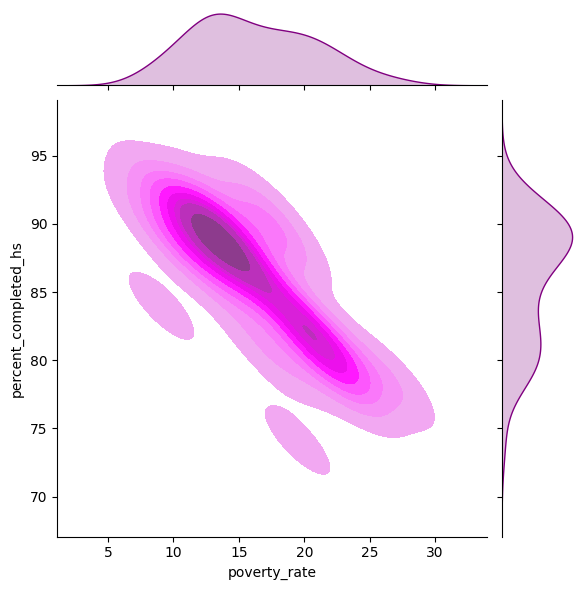

In [30]:
sns.jointplot(
    data=poverty_vs_hs,
    x='poverty_rate',
    y='percent_completed_hs',
    kind='kde',
    fill=True,
    color='purple'
)
plt.show()

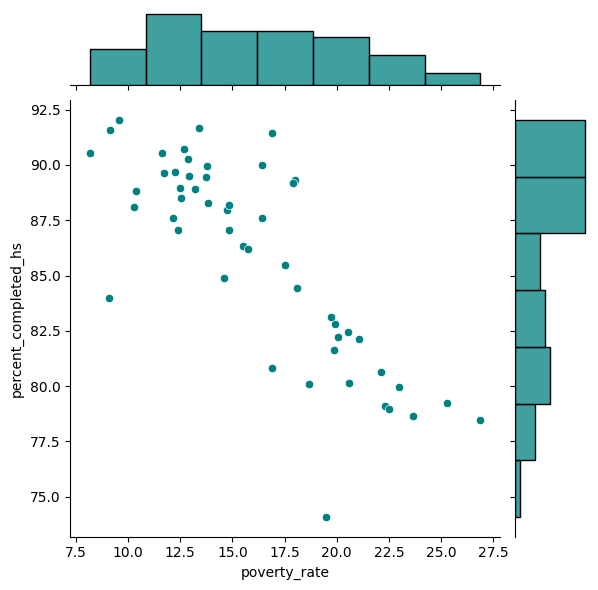

In [31]:
sns.jointplot(
    data=poverty_vs_hs,
    x='poverty_rate',
    y='percent_completed_hs',
    kind='scatter',
    color='teal'
)
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

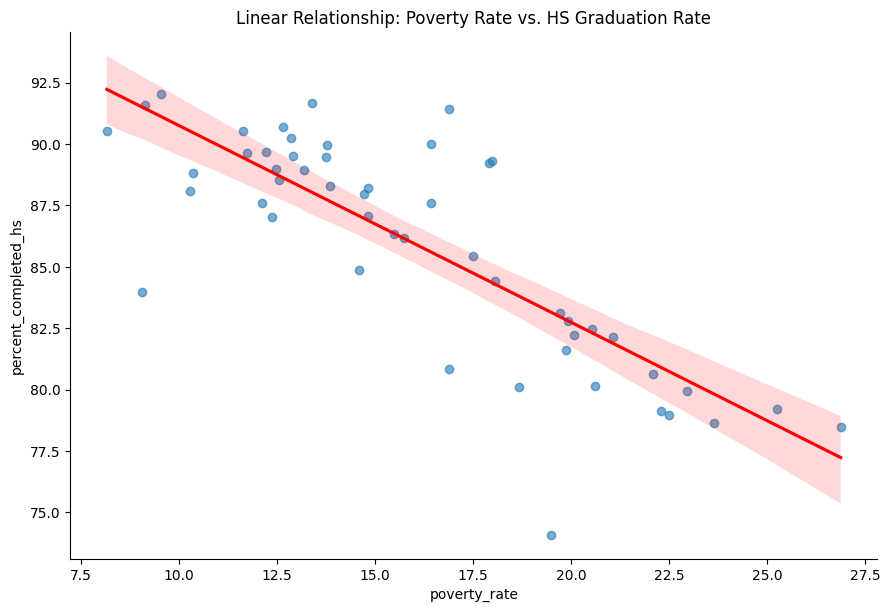

In [32]:
sns.lmplot(
    data=poverty_vs_hs,
    x='poverty_rate',
    y='percent_completed_hs',
    height=6,
    aspect=1.5,
    scatter_kws={'alpha': 0.6},
    line_kws={'color': 'red'}
)
plt.title('Linear Relationship: Poverty Rate vs. HS Graduation Rate')
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [33]:
race_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']

race_by_state = df_share_race_city.groupby('Geographic area')[race_cols].mean().reset_index()
race_by_state.head()

,Geographic area,share_white,share_black,share_native_american,share_asian,share_hispanic
0,AK,45.26,0.56,45.48,1.38,2.13
1,AL,72.51,23.32,0.66,0.48,2.98
2,AR,78.45,16.30,0.76,0.48,4.27
3,AZ,59.93,0.95,28.59,0.73,20.14
4,CA,71.54,2.68,1.72,5.54,29.51


In [34]:
fig = px.bar(
    race_by_state,
    x='Geographic area',
    y=race_cols,
    title='Racial Makeup by US State',
    labels={'value': 'Share of Population (%)', 'Geographic area': 'State', 'variable': 'Race'},
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(barmode='stack', xaxis_title='State', yaxis_title='Share of Population (%)')
fig.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [35]:
race_counts = df_fatalities_clean['race'].value_counts().reset_index()
race_counts.columns = ['race', 'count']
race_counts

,race,count
0,W,1192
1,B,609
2,H,413
3,Unknown,147
4,A,38
5,N,31
6,O,28


In [36]:
fig = px.pie(
    race_counts,
    names='race',
    values='count',
    hole=0.4,
    title='People Killed by Police, by Race',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_traces(textinfo='percent+label')
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

In [37]:
gender_counts = df_fatalities_clean['gender'].value_counts().reset_index()
gender_counts.columns = ['gender', 'count']
gender_counts

,gender,count
0,M,2354
1,F,104


In [38]:
fig = px.bar(
    gender_counts,
    x='gender',
    y='count',
    color='gender',
    title='Total Deaths by Gender',
    labels={'gender': 'Gender', 'count': 'Number of Deaths'},
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.update_layout(showlegend=False)
fig.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death?

In [39]:
df_fatalities_clean['manner_of_death'].value_counts()

,count
manner_of_death,
shot,2290
shot and Tasered,168


In [40]:
fig = px.box (
    df_fatalities_clean,
    x='manner_of_death',
    y='age',
    color='gender',
    title='Age Distribution by Manner of Death and Gender',
    labels={'manner_of_death': 'Manner of Death', 'age': 'Age'},
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.show()

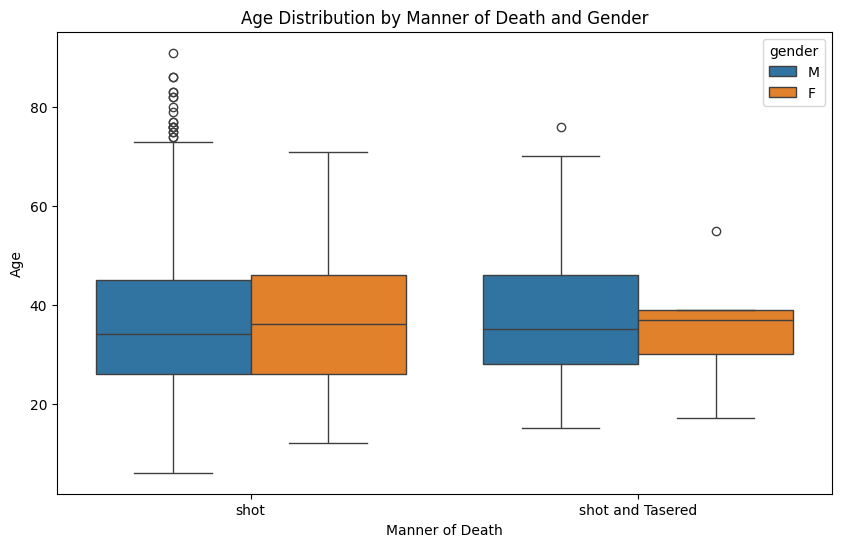

In [42]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fatalities_clean, x='manner_of_death', y='age', hue='gender')
plt.title('Age Distribution by Manner of Death and Gender')
plt.xlabel('Manner of Death')
plt.ylabel('Age')
plt.show()

# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [43]:
armed_status = df_fatalities_clean['armed'].apply(lambda x: 'unarmed' if x == 'unarmed' else 'armed')
armed_pct = armed_status.value_counts(normalize=True) * 100
print(armed_pct)

armed
armed     93.08
unarmed    6.92
Name: proportion, dtype: float64


In [44]:
weapon_counts = df_fatalities_clean['armed'].value_counts().reset_index()
weapon_counts.columns = ['weapon', 'count']

fig = px.bar(
    weapon_counts.head(15),
    x='weapon',
    y='count',
    title='Weapons Carried by People Killed by Police (Top 15)',
    labels={'weapon': 'Weapon Type', 'count': 'Number of Deaths'},
    color='count',
    color_continuous_scale='Oranges'
)

fig.update_layout(xaxis_title='Weapon Type', yaxis_title='Number of Deaths')
fig.show()

In [45]:
gun_vs_unarmed = df_fatalities_clean[df_fatalities_clean['armed'].isin(['gun', 'unarmed'])]
gun_unarmed_counts = gun_vs_unarmed['armed'].value_counts().reset_index()
gun_unarmed_counts.columns = ['armed', 'count']

fig = px.bar(
    gun_unarmed_counts,
    x='armed',
    y='count',
    color='armed',
    title='Gun vs. Unarmed Deaths',
    labels={'armed': 'Status', 'count': 'Number of Deaths'},
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(showlegend=False)
fig.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.




In [46]:
pct_under_25 = (df_fatalities_clean['age'] < 25).sum() / len(df_fatalities_clean) * 100
print(f"Percentage of people killed who were under 25: {pct_under_25:.2f}%")

Percentage of people killed who were under 25: 18.31%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

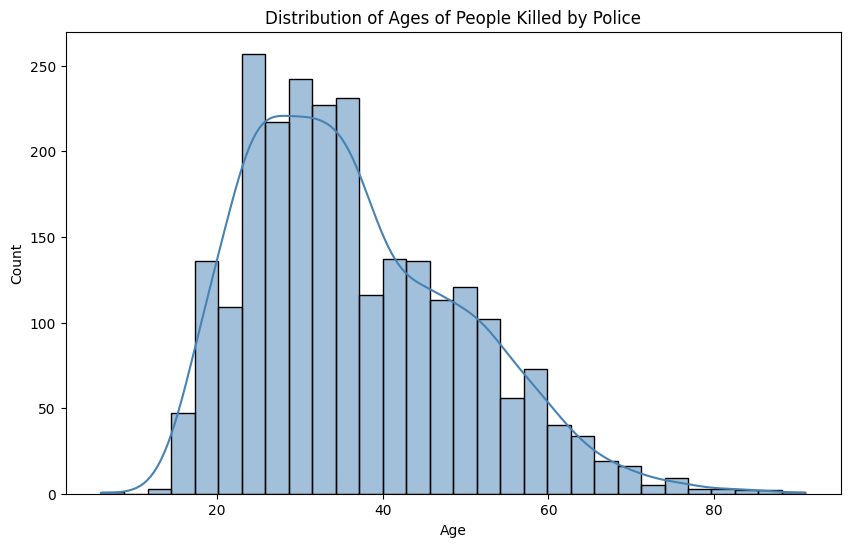

In [47]:
plt.figure(figsize=(10, 6))
sns.histplot(df_fatalities_clean['age'], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Ages of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions?

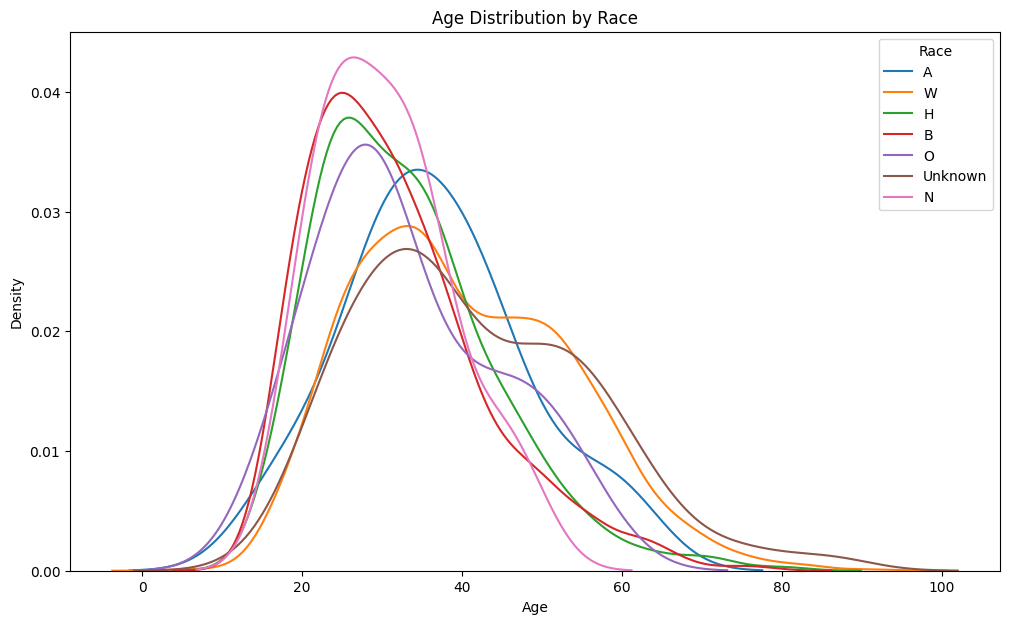

In [49]:
plt.figure(figsize=(12, 7))
for race in df_fatalities_clean['race'].dropna().unique():
  subset = df_fatalities_clean[df_fatalities_clean['race'] == race]
  sns.kdeplot(subset['age'], label=race, fill=False)

plt.title('Age Distribution by Race')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend(title='Race')
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race.

In [50]:
race_labels = {'W': 'White', 'B': 'Black', 'H': 'Hispanic', 'A': 'Asian', 'N': 'Native American', 'O': 'Others', 'Unknown': 'Unknown'}

race_totals = df_fatalities_clean['race'].map(race_labels).value_counts().reset_index()
race_totals.columns = ['race', 'count']
race_totals

,race,count
0,White,1192
1,Black,609
2,Hispanic,413
3,Unknown,147
4,Asian,38
5,Native American,31
6,Others,28


In [51]:
fig = px.bar(
    race_totals,
    x='race',
    y='count',
    color='race',
    title='Total Number of People Killed by Police, by Race',
    labels={'race': 'Race', 'count': 'Number of Deaths'},
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(showlegend=False, xaxis={'categoryorder':'total descending'})
fig.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [52]:
pct_mental_illness = df_fatalities_clean['signs_of_mental_illness'].value_counts(normalize=True) * 100
print(pct_mental_illness)

signs_of_mental_illness
False   74.82
True    25.18
Name: proportion, dtype: float64


In [53]:
mi_counts = df_fatalities_clean['signs_of_mental_illness'].value_counts().reset_index()
mi_counts.columns = ['signs_of_mental_illness', 'count']

fig = px.pie(
    mi_counts,
    names='signs_of_mental_illness',
    values='count',
    hole=0.4,
    title='Police Killings: Signs of Mental Illness',
    color_discrete_sequence=px.colors.qualitative.Pastel1
)

fig.update_traces(textinfo='percent+label')
fig.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [54]:
top_cities = df_fatalities_clean['city'].value_counts().head(10).reset_index()
top_cities.columns = ['city', 'count']
top_cities

,city,count
0,Los Angeles,37
1,Phoenix,30
2,Houston,26
3,Chicago,25
4,Las Vegas,19
5,Columbus,18
6,Austin,18
7,San Antonio,17
8,Miami,17
9,St. Louis,15


In [56]:
fig = px.bar(
    top_cities,
    x='city',
    y='count',
    color='count',
    title='Top 10 US Cities by Number of Police Killings',
    labels={'city': 'City', 'count': 'Number of Killings'},
    color_continuous_scale='Reds'
)

fig.update_layout(xaxis_title='City', yaxis_title='Number of Killings', xaxis={'categoryorder':'total descending'})
fig.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

In [57]:
# Use city+state as the key, since city names repeat across states
df_fatalities_clean['city_state'] = df_fatalities_clean['city'] + ', ' + df_fatalities_clean['state']
top_10_cities_list = df_fatalities_clean['city_state'].value_counts().head(10).index.tolist()

# Census city names have suffixes ("city", "town", "CDP") that fatalities data doesn't — strip them to match
df_share_race_city['city_clean'] = df_share_race_city['City'].str.replace(
    r' city| town| CDP| village| borough| municipality', '', regex=True
)
df_share_race_city['city_state'] = df_share_race_city['city_clean'] + ', ' + df_share_race_city['Geographic area']

race_cols = ['share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
top_10_race_share = df_share_race_city[df_share_race_city['city_state'].isin(top_10_cities_list)]
top_10_race_long = top_10_race_share.melt(id_vars='city_state', value_vars=race_cols, var_name='race', value_name='pct_share')

deaths_by_city_race = df_fatalities_clean[df_fatalities_clean['city_state'].isin(top_10_cities_list)]
deaths_by_city_race_counts = deaths_by_city_race.groupby(['city_state', 'race']).size().reset_index(name='death_count')

print(top_10_race_long.head())
print(deaths_by_city_race_counts.head())

        city_state         race  pct_share
0      Phoenix, AZ  share_white      65.90
1  Los Angeles, CA  share_white      49.80
2        Miami, FL  share_white      72.60
3      Chicago, IL  share_white      45.00
4    St. Louis, MO  share_white      43.90
    city_state race  death_count
0   Austin, TX    B            3
1   Austin, TX    H            2
2   Austin, TX    W           11
3  Chicago, IL    B           21
4  Chicago, IL    H            1


/tmp/ipykernel_706/735445200.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fatalities_clean['city_state'] = df_fatalities_clean['city'] + ', ' + df_fatalities_clean['state']


In [58]:
fig1 = px.bar(
    top_10_race_long, x='city_state', y='pct_share', color='race', barmode='group',
    title='Racial Population Share in Top 10 Cities (by Police Killings)'
)
fig1.update_layout(xaxis_title='City', yaxis_title='Population Share (%)')
fig1.show()

fig2 = px.bar(
    deaths_by_city_race_counts, x='city_state', y='death_count', color='race', barmode='group',
    title='Police Killings by Race in Top 10 Cities'
)
fig2.update_layout(xaxis_title='City', yaxis_title='Number of Killings')
fig2.show()

# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty?

In [59]:
killings_by_state = df_fatalities_clean['state'].value_counts().reset_index()
killings_by_state.columns = ['state', 'count']
killings_by_state

,state,count
0,CA,404
1,TX,215
2,FL,148
3,AZ,113
4,OH,76
5,OK,76
6,CO,70
7,NC,68
8,GA,68
9,MO,64


In [60]:
fig = px.choropleth(
    killings_by_state,
    locations='state',
    locationmode='USA-states',
    color='count',
    color_continuous_scale='Reds',
    scope='usa',
    title='Total Police Killings by US State (2015-Present)',
    labels={'count': 'Number of Killings'}
)

fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data?

In [61]:
df_fatalities_clean['date'] = pd.to_datetime(df_fatalities_clean['date'], format='%d/%m/%y')
df_fatalities_clean[['date']].head()

/tmp/ipykernel_706/342386926.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fatalities_clean['date'] = pd.to_datetime(df_fatalities_clean['date'], format='%d/%m/%y')


,date
0,2015-01-02
1,2015-01-02
2,2015-01-03
3,2015-01-04
4,2015-01-04


In [62]:
killings_over_time = df_fatalities_clean.set_index('date').resample('ME').size().reset_index()
killings_over_time.columns = ['date', 'count']
killings_over_time.head()

,date,count
0,2015-01-31,76
1,2015-02-28,76
2,2015-03-31,92
3,2015-04-30,84
4,2015-05-31,71


In [63]:
fig = px.line(
    killings_over_time,
    x='date',
    y='count',
    title='Number of Police Killings Over Time (Monthly)',
    labels={'date': 'Date', 'count': 'Number of Killings'}
)

fig.update_traces(mode='lines+markers')
fig.show()

In [64]:
killings_over_time['rolling_avg'] = killings_over_time['count'].rolling(window=3).mean()

fig = px.line(
    killings_over_time,
    x='date',
    y=['count', 'rolling_avg'],
    title='Number of Police Killings Over Time with 3-Month Rolling Average',
    labels={'date': 'Date', 'value': 'Number of Killings', 'variable': 'Series'}
)

fig.show()